# Week 1 Project: Semiconductor Wafer EDA
**Gautham's AI Learning Path — Phase 1, Week 1**

**Goal:** Load the SECOM semiconductor manufacturing dataset, clean it, explore it, and extract meaningful patterns using Python's data stack.

**Dataset:** SECOM — real semiconductor manufacturing data from UCI ML Repository  
- 1567 wafer runs × 591 sensor/process measurements  
- Binary yield label: +1 = pass, -1 = fail  
- ~93% pass rate (heavily imbalanced — note this for Week 2)

**Skills practiced:** NumPy, Pandas, Matplotlib, Seaborn, basic statistics  
**Time:** ~60 min/day across 5 days  

---

## Setup: Install & Import
Run this cell first. If any import fails, run the install cell below it.

In [1]:
# If you need to install anything, uncomment and run:
# !pip install numpy pandas matplotlib seaborn scikit-learn requests

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
import requests
import io

warnings.filterwarnings('ignore')

# Notebook display settings
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

print('All imports OK')
print(f'NumPy  {np.__version__}')
print(f'Pandas {pd.__version__}')

All imports OK
NumPy  2.4.2
Pandas 2.3.3


---
## Day 1 — Load & First Look
**Monday: Get the data in, understand its shape, catch your first surprises.**

In [4]:
# ── Download SECOM dataset from UCI (auto-downloads, no manual steps needed) ──
#
# Two files:
#   secom.data  — 1567 rows × 591 features (space-separated, NaN = missing)
#   secom_labels.data — 1567 rows × 2 cols (label: +1=pass/-1=fail, timestamp)

print('Downloading SECOM dataset from UCI ML Repository...')

features_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom.data'
labels_url   = 'https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom_labels.data'

features_raw = requests.get(features_url).text
labels_raw   = requests.get(labels_url).text

# Parse into DataFrames
X = pd.read_csv(io.StringIO(features_raw), sep=' ', header=None)
X.columns = [f'sensor_{i:03d}' for i in range(X.shape[1])]

labels_df = pd.read_csv(io.StringIO(labels_raw), sep=' ', header=None,
                        names=['label', 'timestamp'])
labels_df['timestamp'] = pd.to_datetime(labels_df['timestamp'])
labels_df['pass'] = (labels_df['label'] == 1).astype(int)  # 1=pass, 0=fail

# Merge into one DataFrame
df = pd.concat([X, labels_df.reset_index(drop=True)], axis=1)

print(f'Download complete!')
print(f'Shape: {df.shape[0]} wafer runs × {X.shape[1]} sensors + labels')

Download complete!
Shape: 1567 wafer runs × 590 sensors + labels


In [8]:
# ── First look ──
print('=== DATASET OVERVIEW ===')
print(f'Wafer runs       : {len(df):,}')
print(f'Sensor features  : {X.shape[1]}')
print(f'Date range       : {labels_df.timestamp.min().date()} → {labels_df.timestamp.max().date()}')
print(f'Pass rate        : {labels_df["pass"].mean():.1%}')
print(f'Fail rate        : {1 - labels_df["pass"].mean():.1%}')
print()
print('--- First 3 rows (first 8 sensors) ---')
display(df[list(X.columns[:8]) + ['label', 'timestamp']].head(3))

=== DATASET OVERVIEW ===
Wafer runs       : 1,567
Sensor features  : 590
Date range       : 2008-07-19 → 2008-10-17
Pass rate        : 6.6%
Fail rate        : 93.4%

--- First 3 rows (first 8 sensors) ---


,sensor_000,sensor_001,sensor_002,sensor_003,sensor_004,sensor_005,sensor_006,sensor_007,label,timestamp
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,-1,2008-07-19 11:55:00
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,-1,2008-07-19 12:32:00
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1,2008-07-19 13:17:00


Sensors with ANY missing data : 538
Sensors with >80% missing     : 8
Sensors with >50% missing     : 28

Top 10 most incomplete sensors:
sensor_157    91.193363
sensor_292    91.193363
sensor_293    91.193363
sensor_158    91.193363
sensor_492    85.577537
sensor_358    85.577537
sensor_085    85.577537
sensor_220    85.577537
sensor_246    64.964901
sensor_109    64.964901


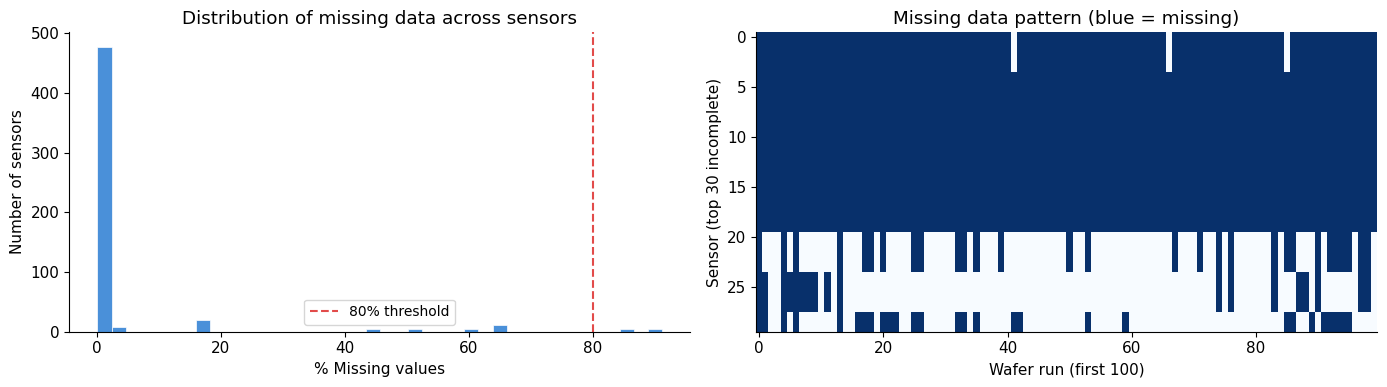

Saved: missing_data_audit.png


In [9]:
# ── Missing data audit — this is a real problem in semiconductor data ──
missing = X.isnull().sum()
missing_pct = (missing / len(X) * 100).sort_values(ascending=False)

print(f'Sensors with ANY missing data : {(missing > 0).sum()}')
print(f'Sensors with >80% missing     : {(missing_pct > 80).sum()}')
print(f'Sensors with >50% missing     : {(missing_pct > 50).sum()}')
print()
print('Top 10 most incomplete sensors:')
print(missing_pct.head(10).to_string())

# ── Visualize missing data distribution ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.hist(missing_pct[missing_pct > 0], bins=40, color='#4A90D9', edgecolor='white', linewidth=0.5)
ax1.set_xlabel('% Missing values')
ax1.set_ylabel('Number of sensors')
ax1.set_title('Distribution of missing data across sensors')
ax1.axvline(80, color='#E24B4A', linestyle='--', linewidth=1.5, label='80% threshold')
ax1.legend(fontsize=10)

# Missing data heatmap (sample of sensors)
sample_sensors = missing_pct[missing_pct > 10].head(30).index.tolist()
if sample_sensors:
    missing_matrix = X[sample_sensors].isnull().astype(int).iloc[:100]
    ax2.imshow(missing_matrix.T, aspect='auto', cmap='Blues', interpolation='none')
    ax2.set_xlabel('Wafer run (first 100)')
    ax2.set_ylabel('Sensor (top 30 incomplete)')
    ax2.set_title('Missing data pattern (blue = missing)')

plt.tight_layout()
plt.savefig('missing_data_audit.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: missing_data_audit.png')

---
## Day 2 — NumPy Operations & Data Cleaning
**Tuesday: Use NumPy to understand the data numerically. Clean it for analysis.**

In [13]:
# ── NumPy operations on the sensor matrix ──
# Convert to numpy for matrix-level operations (as you would in MATLAB)
X_arr = X.values  # shape: (1567, 591)

print(f'Sensor matrix shape: {X_arr.shape}')
print(f'dtype: {X_arr.dtype}')
print()

# Column-wise statistics (ignoring NaN)
col_means = np.nanmean(X_arr, axis=0)   # mean per sensor
col_stds  = np.nanstd(X_arr,  axis=0)   # std per sensor
col_ranges = np.nanmax(X_arr, axis=0) - np.nanmin(X_arr, axis=0)

print('Per-sensor statistics (first 5 sensors):')
print(f'  Means  : {col_means[:5].round(4)}')
print(f'  Stds   : {col_stds[:5].round(4)}')
print(f'  Ranges : {col_ranges[:5].round(4)}')

Sensor matrix shape: (1567, 590)
dtype: float64

Per-sensor statistics (first 5 sensors):
  Means  : [3014.4529 2495.8502 2200.5473 1396.3766    4.197 ]
  Stds   : [ 73.5982  80.3819  29.5036 441.5494  56.3374]
  Ranges : [ 613.11    687.69    254.6067 3715.0417 1113.8551]


In [14]:
# ── Find zero-variance sensors (useless for ML — no signal) ──
zero_var_mask = col_stds < 1e-6
print(f'Zero-variance sensors (constant values): {zero_var_mask.sum()}')

# ── Drop sensors: >50% missing OR zero variance ──
high_missing_mask = (missing_pct > 50).values
drop_mask = high_missing_mask | zero_var_mask

X_clean = X.loc[:, ~drop_mask].copy()
print(f'Sensors before cleaning : {X.shape[1]}')
print(f'Sensors dropped         : {drop_mask.sum()}')
print(f'Sensors remaining       : {X_clean.shape[1]}')

# ── Impute remaining missing values with column median ──
# Median is more robust than mean for sensor data with outliers
X_clean = X_clean.fillna(X_clean.median())
print(f'Missing values after imputation: {X_clean.isnull().sum().sum()}')

Zero-variance sensors (constant values): 116
Sensors before cleaning : 590
Sensors dropped         : 142
Sensors remaining       : 448
Missing values after imputation: 0


In [15]:
# ── Vectorized NumPy: compute coefficient of variation (CV) per sensor ──
# CV = std/mean — a normalized measure of variability, common in fab process control
X_vals = X_clean.values
means  = np.mean(X_vals, axis=0)
stds   = np.std(X_vals,  axis=0)

# Avoid division by zero for near-zero mean sensors
with np.errstate(divide='ignore', invalid='ignore'):
    cv = np.where(np.abs(means) > 1e-6, stds / np.abs(means), 0)

cv_series = pd.Series(cv, index=X_clean.columns, name='cv')

print('Top 10 highest-variability sensors (by CV):')
print(cv_series.sort_values(ascending=False).head(10).round(3).to_string())
print()
print('Note: high-CV sensors are candidates for process monitoring priorities')

Top 10 highest-variability sensors (by CV):
sensor_104    58.157
sensor_102    56.584
sensor_107    49.614
sensor_099    40.803
sensor_074    39.573
sensor_347    39.573
sensor_342    39.573
sensor_206    39.573
sensor_478    39.573
sensor_209    39.573

Note: high-CV sensors are candidates for process monitoring priorities


---
## Day 3 — Pandas Analysis: Pass vs Fail
**Wednesday: Use Pandas groupby and aggregation to find differences between passing and failing wafers.**

In [16]:
# ── Build analysis DataFrame ──
analysis = X_clean.copy()
analysis['label']     = labels_df['label'].values
analysis['pass']      = labels_df['pass'].values
analysis['timestamp'] = labels_df['timestamp'].values

pass_df = analysis[analysis['pass'] == 1]
fail_df = analysis[analysis['pass'] == 0]

print(f'Pass wafers: {len(pass_df):,}  ({len(pass_df)/len(analysis):.1%})')
print(f'Fail wafers: {len(fail_df):,}  ({len(fail_df)/len(analysis):.1%})')

Pass wafers: 104  (6.6%)
Fail wafers: 1,463  (93.4%)


In [17]:
# ── Sensor-level t-test: which sensors differ most between pass and fail? ──
# This is a simplified version of what FDC systems do in production

sensor_cols = X_clean.columns.tolist()

results = []
for col in sensor_cols:
    p_vals = pass_df[col].dropna().values
    f_vals = fail_df[col].dropna().values
    if len(p_vals) > 5 and len(f_vals) > 5:
        t_stat, p_val = stats.ttest_ind(p_vals, f_vals)
        effect_size = (p_vals.mean() - f_vals.mean()) / (np.std(p_vals) + 1e-9)
        results.append({
            'sensor': col,
            'pass_mean': p_vals.mean(),
            'fail_mean': f_vals.mean(),
            'p_value': p_val,
            'effect_size': abs(effect_size)
        })

results_df = pd.DataFrame(results).sort_values('p_value')

print('Top 15 sensors most different between pass and fail wafers:')
display(results_df.head(15).round(4).reset_index(drop=True))

# Store top discriminating sensors for later analysis
top_sensors = results_df.head(20)['sensor'].tolist()

Top 15 sensors most different between pass and fail wafers:


,sensor,pass_mean,fail_mean,p_value,effect_size
0,sensor_059,8.5151,2.5557,0.0000,0.5543
1,sensor_103,-0.0081,-0.0099,0.0000,0.5345
2,sensor_510,74.3479,54.4304,0.0000,0.3617
3,sensor_348,0.0304,0.0243,0.0000,0.2588
4,sensor_431,38.7073,21.1879,0.0000,0.2385
5,sensor_434,28.9548,13.7168,0.0000,0.2095
6,sensor_430,33.1561,17.3642,0.0000,0.2149
7,sensor_435,23.3070,8.3734,0.0000,0.2022
8,sensor_028,68.1115,69.5977,0.0000,0.4573
9,sensor_436,21.2487,6.5304,0.0000,0.1980


In [18]:
# ── Pandas groupby: aggregate stats by pass/fail ──
top5 = top_sensors[:5]

grouped = analysis.groupby('pass')[top5].agg(['mean', 'std', 'median'])
grouped.index = ['Fail', 'Pass']
print('Pass vs Fail — mean/std/median for top 5 discriminating sensors:')
display(grouped.round(3))

Pass vs Fail — mean/std/median for top 5 discriminating sensors:


sensor_059                sensor_103               sensor_510          \
           mean     std median       mean    std median       mean     std   
Fail      2.556   9.291  0.748     -0.010  0.003 -0.010     54.430  35.746   
Pass      8.515  10.802  5.522     -0.008  0.003 -0.008     74.348  55.337   

             sensor_348               sensor_431                  
      median       mean    std median       mean     std  median  
Fail  46.412      0.024  0.010  0.023     21.188  31.825  16.213  
Pass  58.232      0.030  0.024  0.025     38.707  73.815  18.380

---
## Day 4 — Visualization
**Thursday: Build publication-quality plots that communicate findings clearly.**

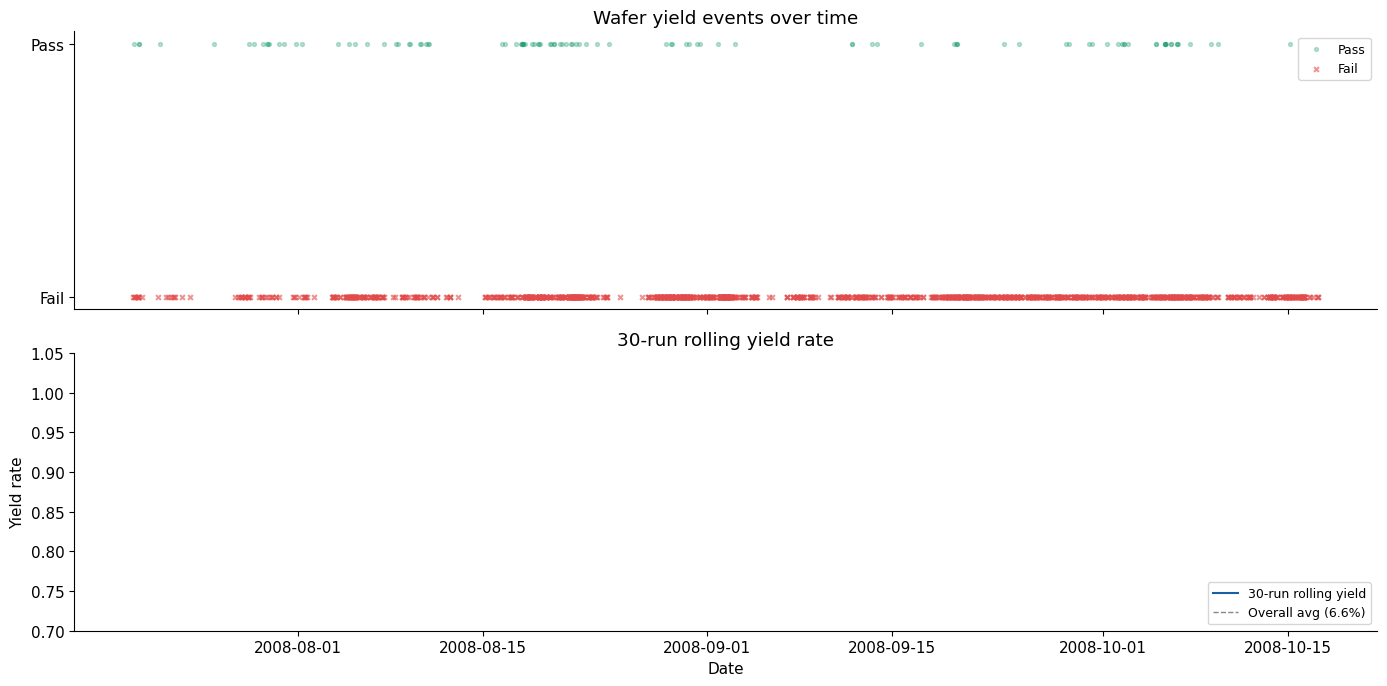

Saved: yield_over_time.png


In [19]:
# ── Plot 1: Yield over time ──
analysis_ts = analysis.copy()
analysis_ts['timestamp'] = pd.to_datetime(analysis_ts['timestamp'])
analysis_ts = analysis_ts.sort_values('timestamp')

# Rolling yield rate (30-run window)
analysis_ts['rolling_yield'] = analysis_ts['pass'].rolling(window=30, min_periods=10).mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Top: individual pass/fail events
ax1.scatter(analysis_ts['timestamp'][analysis_ts['pass']==1],
            [1]*sum(analysis_ts['pass']==1),
            c='#1D9E75', alpha=0.3, s=8, label='Pass')
ax1.scatter(analysis_ts['timestamp'][analysis_ts['pass']==0],
            [0]*sum(analysis_ts['pass']==0),
            c='#E24B4A', alpha=0.6, s=12, label='Fail', marker='x')
ax1.set_yticks([0, 1])
ax1.set_yticklabels(['Fail', 'Pass'])
ax1.set_title('Wafer yield events over time')
ax1.legend(loc='upper right', fontsize=9)

# Bottom: rolling yield rate
ax2.plot(analysis_ts['timestamp'], analysis_ts['rolling_yield'],
         color='#185FA5', linewidth=1.5, label='30-run rolling yield')
ax2.axhline(analysis_ts['pass'].mean(), color='#888780', linestyle='--',
            linewidth=1, label=f'Overall avg ({analysis_ts["pass"].mean():.1%})')
ax2.fill_between(analysis_ts['timestamp'], analysis_ts['rolling_yield'],
                 analysis_ts['pass'].mean(), alpha=0.1, color='#185FA5')
ax2.set_ylim(0.7, 1.05)
ax2.set_ylabel('Yield rate')
ax2.set_xlabel('Date')
ax2.set_title('30-run rolling yield rate')
ax2.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('yield_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: yield_over_time.png')

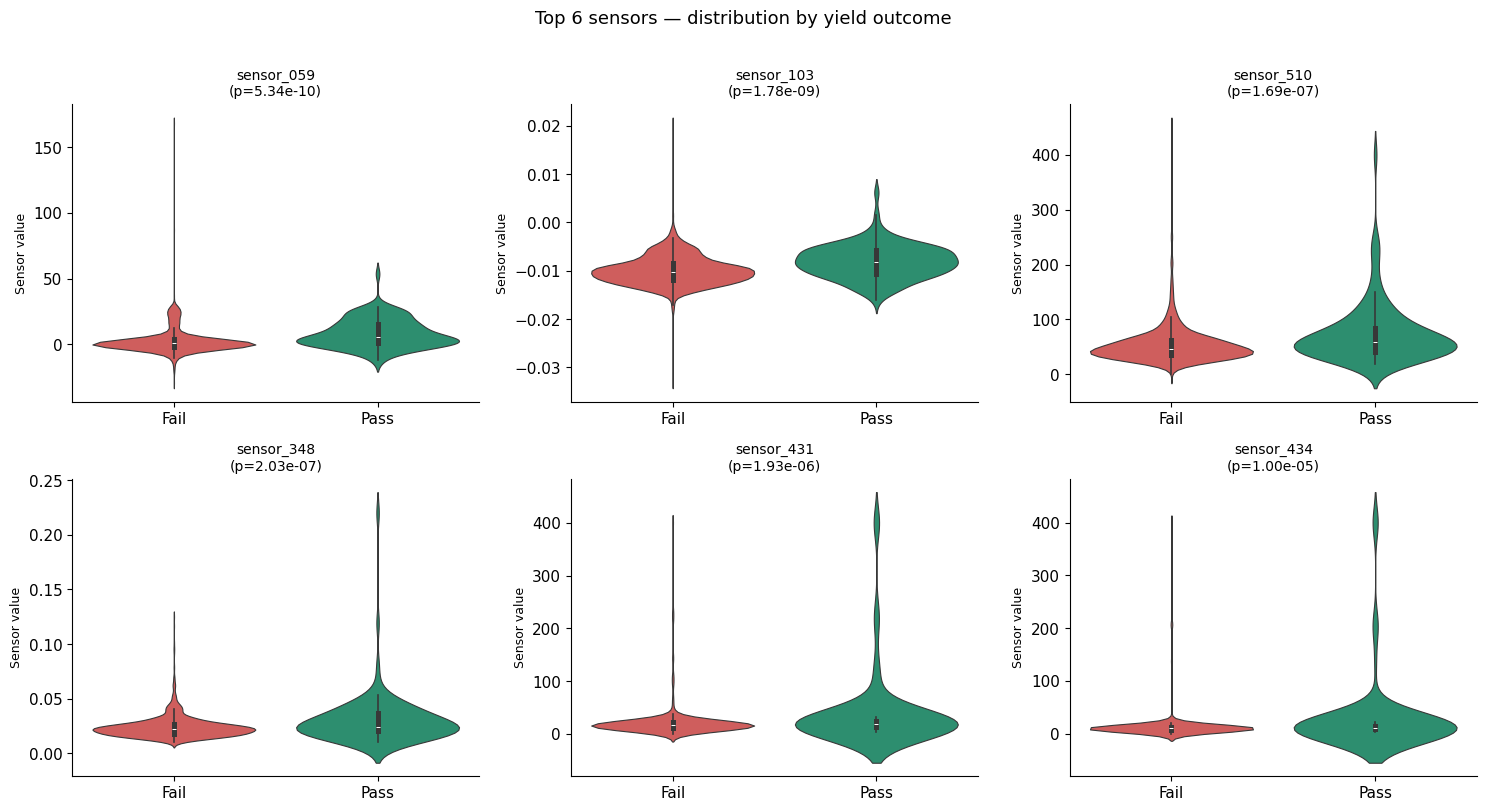

Saved: sensor_distributions.png


In [20]:
# ── Plot 2: Sensor distributions — pass vs fail ──
# Violin + strip plots for top 6 discriminating sensors

plot_sensors = top_sensors[:6]
plot_data = analysis[plot_sensors + ['pass']].melt(
    id_vars='pass', value_vars=plot_sensors,
    var_name='sensor', value_name='value'
)
plot_data['outcome'] = plot_data['pass'].map({1: 'Pass', 0: 'Fail'})

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, sensor in enumerate(plot_sensors):
    ax = axes[i]
    sensor_data = analysis[[sensor, 'pass']].copy()
    sensor_data['outcome'] = sensor_data['pass'].map({1: 'Pass', 0: 'Fail'})

    sns.violinplot(data=sensor_data, x='outcome', y=sensor,
                  palette={'Pass': '#1D9E75', 'Fail': '#E24B4A'},
                  inner='box', ax=ax, linewidth=0.8)

    p_val = results_df[results_df['sensor'] == sensor]['p_value'].values[0]
    ax.set_title(f'{sensor}\n(p={p_val:.2e})', fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Sensor value', fontsize=9)

plt.suptitle('Top 6 sensors — distribution by yield outcome', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('sensor_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sensor_distributions.png')

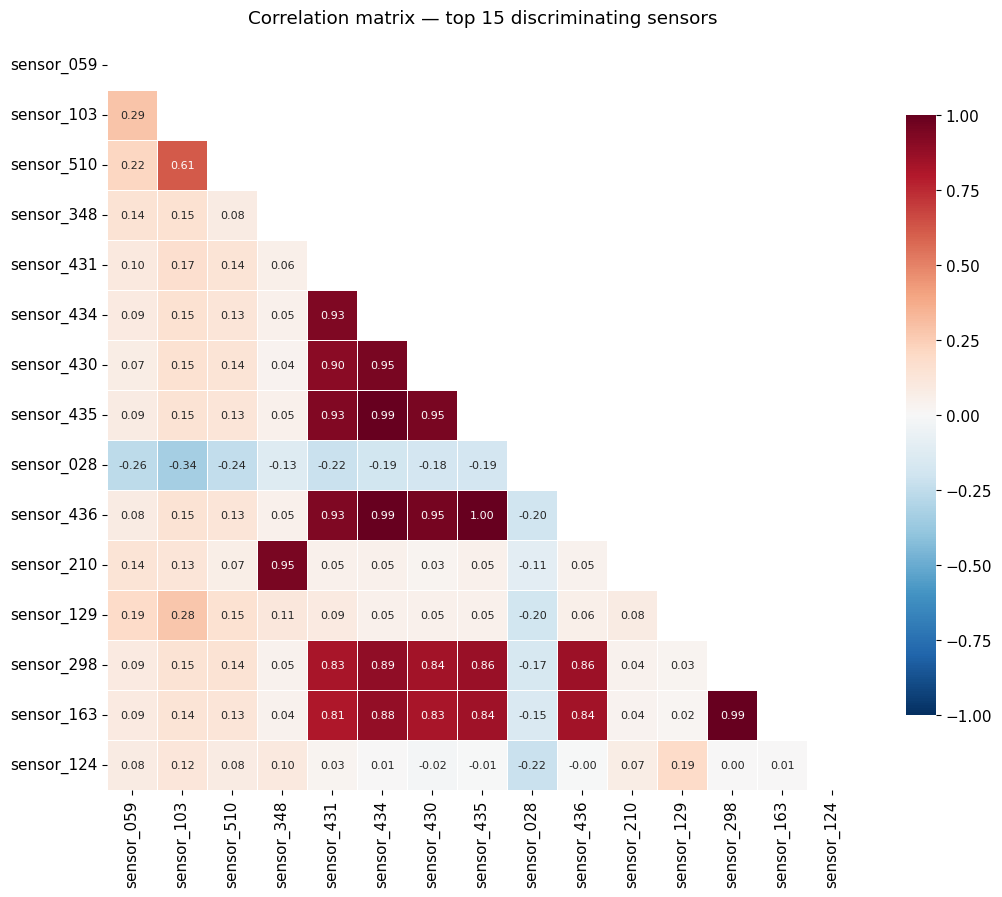

Saved: sensor_correlation.png

Note: highly correlated sensor pairs (|r| > 0.8) are candidates for removal
  sensor_348 ↔ sensor_210  (r=0.95)
  sensor_431 ↔ sensor_434  (r=0.933)
  sensor_431 ↔ sensor_430  (r=0.899)
  sensor_431 ↔ sensor_435  (r=0.93)
  sensor_431 ↔ sensor_436  (r=0.933)
  sensor_431 ↔ sensor_298  (r=0.825)
  sensor_431 ↔ sensor_163  (r=0.811)
  sensor_434 ↔ sensor_430  (r=0.948)
  sensor_434 ↔ sensor_435  (r=0.994)
  sensor_434 ↔ sensor_436  (r=0.992)
  sensor_434 ↔ sensor_298  (r=0.886)
  sensor_434 ↔ sensor_163  (r=0.876)
  sensor_430 ↔ sensor_435  (r=0.952)
  sensor_430 ↔ sensor_436  (r=0.954)
  sensor_430 ↔ sensor_298  (r=0.842)
  sensor_430 ↔ sensor_163  (r=0.827)
  sensor_435 ↔ sensor_436  (r=0.996)
  sensor_435 ↔ sensor_298  (r=0.86)
  sensor_435 ↔ sensor_163  (r=0.845)
  sensor_436 ↔ sensor_298  (r=0.857)
  sensor_436 ↔ sensor_163  (r=0.84)
  sensor_298 ↔ sensor_163  (r=0.993)


In [21]:
# ── Plot 3: Correlation heatmap for top sensors ──
# Which sensors move together? Correlated sensors are redundant for ML.

top15_corr = analysis[top_sensors[:15]].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(top15_corr, dtype=bool))  # hide upper triangle
sns.heatmap(top15_corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation matrix — top 15 discriminating sensors', pad=12)
plt.tight_layout()
plt.savefig('sensor_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sensor_correlation.png')
print()
print('Note: highly correlated sensor pairs (|r| > 0.8) are candidates for removal')
high_corr = []
for i in range(len(top15_corr.columns)):
    for j in range(i+1, len(top15_corr.columns)):
        r = top15_corr.iloc[i, j]
        if abs(r) > 0.8:
            high_corr.append((top15_corr.columns[i], top15_corr.columns[j], round(r, 3)))
if high_corr:
    for pair in high_corr:
        print(f'  {pair[0]} ↔ {pair[1]}  (r={pair[2]})')
else:
    print('  No highly correlated pairs found in top 15 sensors')

---
## Day 5 — Summary Report & Key Findings
**Friday: Synthesize findings into a structured summary. This is your Week 1 deliverable.**

In [22]:
# ── Statistical summary: the numbers that tell the story ──

print('='*60)
print('WEEK 1 DELIVERABLE: SECOM EDA SUMMARY REPORT')
print('='*60)

print()
print('--- Dataset Characteristics ---')
print(f'  Total wafer runs         : {len(df):,}')
print(f'  Original sensor features : {X.shape[1]}')
print(f'  Sensors after cleaning   : {X_clean.shape[1]}')
print(f'  Overall yield (pass rate): {analysis["pass"].mean():.1%}')
print(f'  Date range               : {analysis_ts["timestamp"].min().date()} → {analysis_ts["timestamp"].max().date()}')

print()
print('--- Data Quality Issues ---')
print(f'  Sensors with >50% missing   : {(missing_pct > 50).sum()} (dropped)')
print(f'  Zero-variance sensors        : {zero_var_mask.sum()} (dropped)')
print(f'  Sensors imputed (col median) : {(missing_pct.between(0.01, 50)).sum()}')

print()
print('--- Top 5 Sensors Most Associated with Yield Outcome ---')
for _, row in results_df.head(5).iterrows():
    direction = 'higher in pass' if row['pass_mean'] > row['fail_mean'] else 'higher in fail'
    print(f'  {row["sensor"]:12s}  p={row["p_value"]:.2e}  effect={row["effect_size"]:.3f}  ({direction})')

print()
print('--- Yield Trend Observations ---')
ts_sorted = analysis_ts.sort_values('timestamp')
first_half_yield = ts_sorted.iloc[:len(ts_sorted)//2]['pass'].mean()
second_half_yield = ts_sorted.iloc[len(ts_sorted)//2:]['pass'].mean()
trend = 'improving' if second_half_yield > first_half_yield else 'declining'
print(f'  First half yield  : {first_half_yield:.1%}')
print(f'  Second half yield : {second_half_yield:.1%}')
print(f'  Trend             : {trend} ({abs(second_half_yield - first_half_yield):.1%} delta)')

print()
print('--- What This Means for Week 2 (ML modeling) ---')
print('  1. Class imbalance (93% pass) → use precision-recall, not accuracy')
print('  2. Many correlated sensors → dimensionality reduction (PCA) will help')
print('  3. Top discriminating sensors identified → use as feature selection baseline')
print('  4. Missing data handled → clean dataset ready for sklearn pipeline')
print()
print('Saved outputs:')
print('  missing_data_audit.png')
print('  yield_over_time.png')
print('  sensor_distributions.png')
print('  sensor_correlation.png')
print('='*60)

WEEK 1 DELIVERABLE: SECOM EDA SUMMARY REPORT

--- Dataset Characteristics ---
  Total wafer runs         : 1,567
  Original sensor features : 590
  Sensors after cleaning   : 448
  Overall yield (pass rate): 6.6%
  Date range               : 2008-07-19 → 2008-10-17

--- Data Quality Issues ---
  Sensors with >50% missing   : 28 (dropped)
  Zero-variance sensors        : 116 (dropped)
  Sensors imputed (col median) : 510

--- Top 5 Sensors Most Associated with Yield Outcome ---
  sensor_059    p=5.34e-10  effect=0.554  (higher in pass)
  sensor_103    p=1.78e-09  effect=0.534  (higher in pass)
  sensor_510    p=1.69e-07  effect=0.362  (higher in pass)
  sensor_348    p=2.03e-07  effect=0.259  (higher in pass)
  sensor_431    p=1.93e-06  effect=0.238  (higher in pass)

--- Yield Trend Observations ---
  First half yield  : 8.6%
  Second half yield : 4.7%
  Trend             : declining (3.8% delta)

--- What This Means for Week 2 (ML modeling) ---
  1. Class imbalance (93% pass) → use pr

In [23]:
# ── Save cleaned dataset for Week 2 ──
# You'll load this file at the start of Week 2 instead of re-downloading

save_df = X_clean.copy()
save_df['label'] = labels_df['label'].values
save_df['pass']  = labels_df['pass'].values
save_df['timestamp'] = labels_df['timestamp'].values

save_df.to_csv('secom_clean.csv', index=False)
print(f'Saved cleaned dataset: secom_clean.csv')
print(f'Shape: {save_df.shape}')
print()
print('Load in Week 2 with:')
print("  df = pd.read_csv('secom_clean.csv')")
print("  X  = df.drop(columns=['label', 'pass', 'timestamp'])")
print("  y  = df['pass']")

Saved cleaned dataset: secom_clean.csv
Shape: (1567, 451)

Load in Week 2 with:
  df = pd.read_csv('secom_clean.csv')
  X  = df.drop(columns=['label', 'pass', 'timestamp'])
  y  = df['pass']


---
## Stretch Exercises (if you finish early)

These aren't required for Week 1 but push your skills further:

**Stretch 1:** Plot sensor values over time for your top 3 sensors. Do you see any drift patterns or step changes that correlate with yield drops?

**Stretch 2:** Calculate a rolling 7-day yield rate and find the single worst week in the dataset. Which sensors showed the most anomalous behavior that week?

**Stretch 3:** Build an interactive dashboard using `plotly.express` instead of matplotlib. Plotly charts are zoomable and hoverable — much more useful for exploratory analysis.

**Stretch 4:** Research question — the SECOM dataset has 591 sensors. In a real fab, these would include measurements from etch rate monitors, endpoint detection, chamber pressure, RF power, gas flows, and more. Based on your LAM/AMAT background: which of the top discriminating sensors do you think correspond to which physical measurements?

---
## Week 2 Preview

Next week you'll load `secom_clean.csv` and build your first **ML classifier**:
- Logistic regression → predict pass/fail from sensor values
- Handle the class imbalance problem properly
- Evaluate with precision-recall curves, not just accuracy
- Build a full `sklearn` pipeline with preprocessing + model

The sensor analysis you did today (especially the t-test rankings) will directly inform which features matter most.

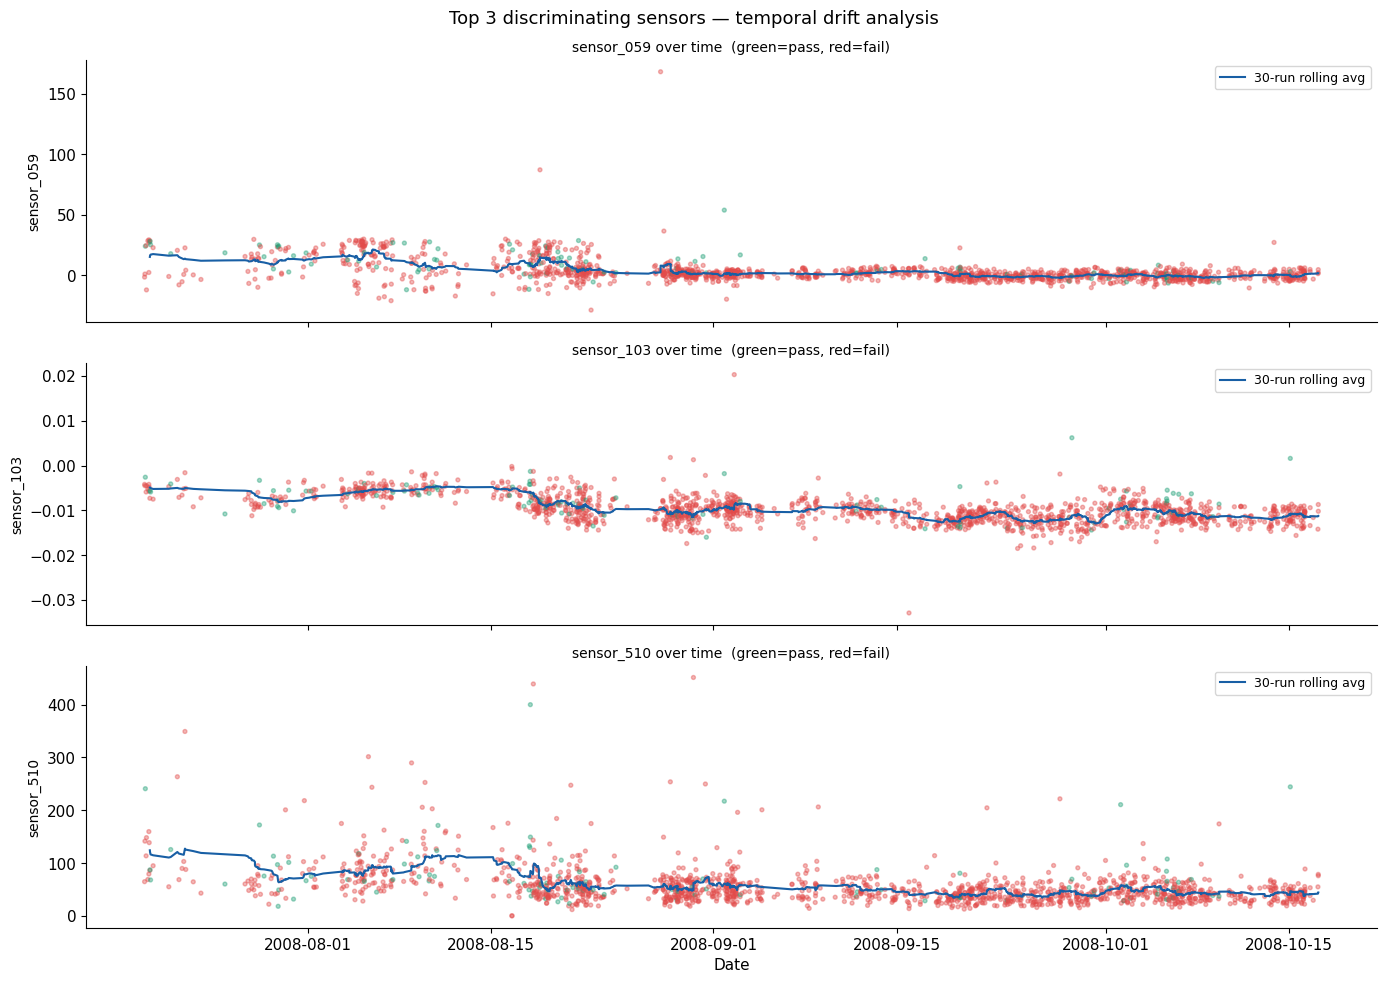

Saved: sensor_drift.png


In [24]:
# Stretch 1: Top 3 sensors over time
top3 = top_sensors[:3]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, sensor in enumerate(top3):
    ax = axes[i]
    
    # Plot sensor value over time
    ax.scatter(analysis_ts['timestamp'], analysis_ts[sensor],
               c=analysis_ts['pass'].map({1: '#1D9E75', 0: '#E24B4A'}),
               alpha=0.4, s=8)
    
    # Rolling average to show trend
    rolling = analysis_ts[sensor].rolling(window=30, min_periods=10).mean()
    ax.plot(analysis_ts['timestamp'], rolling,
            color='#185FA5', linewidth=1.5, label='30-run rolling avg')
    
    ax.set_ylabel(sensor, fontsize=10)
    ax.set_title(f'{sensor} over time  (green=pass, red=fail)', fontsize=10)
    ax.legend(fontsize=9)

axes[-1].set_xlabel('Date')
plt.suptitle('Top 3 discriminating sensors — temporal drift analysis', fontsize=13)
plt.tight_layout()
plt.savefig('sensor_drift.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sensor_drift.png')